In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


https://github.com/pungsonbaggy/audio_exercise.git

In [2]:
!pip install librosa matplotlib numpy scipy pydub soundfile

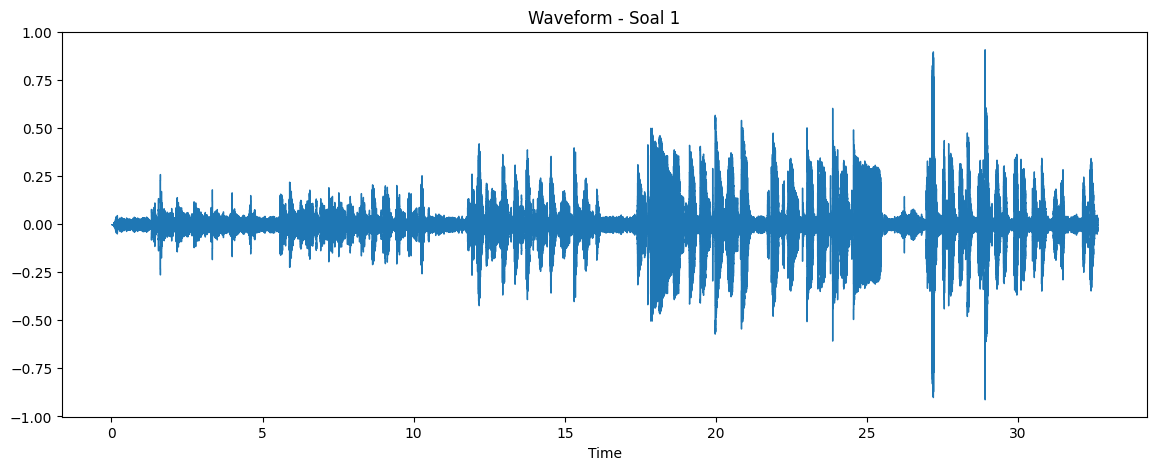

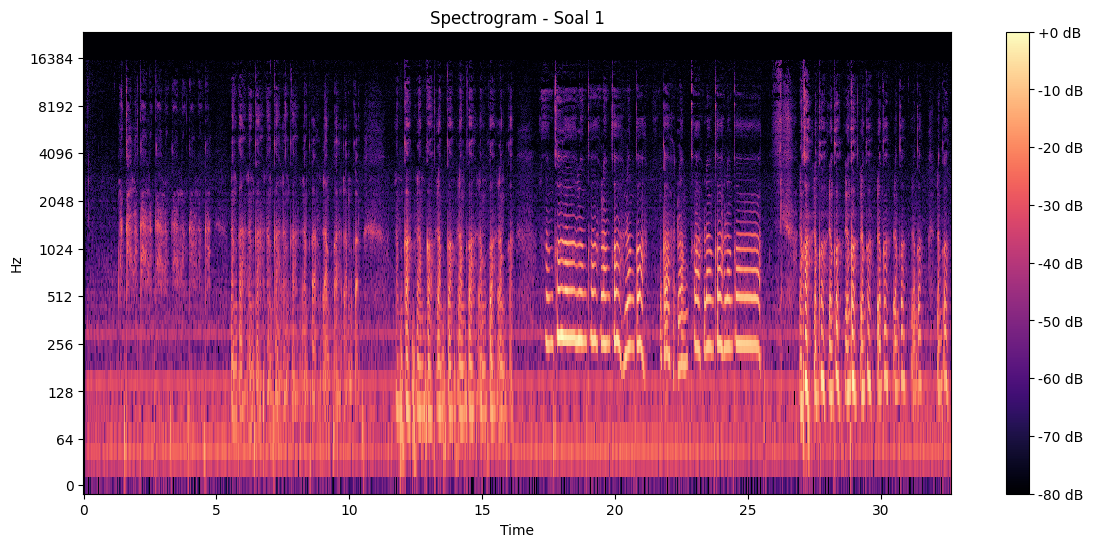

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load audio
y, sr = librosa.load('/content/drive/MyDrive/audio_exercise/raw/soal1_raw.wav', sr=None)

# Plot waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform - Soal 1')
plt.show()

# Plot spectrogram
plt.figure(figsize=(14, 6))
D = librosa.stft(y)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                         sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram - Soal 1')
plt.show()

Pada waveform, terlihat perubahan amplitudo: sangat rendah saat bisik, meningkat saat normal & keras, lalu pola frekuensi berubah saat cempreng dan teriak. Spektrogram menunjukkan energi frekuensi rendah dominan saat bisik, sedangkan saat teriak muncul energi tinggi di frekuensi menengah-tinggi.

In [6]:
# Resample ke 16000 Hz
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=16000)

# Simpan
import soundfile as sf
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal1_resampled.wav', y_resampled, 16000)

# Bandingkan durasi & kualitas yang dibuat tadi
print(f"Asli: {len(y)/sr:.2f} detik, SR={sr} Hz")
print(f"Resampled: {len(y_resampled)/16000:.2f} detik, SR=16000 Hz")

Asli: 32.64 detik, SR=48000 Hz
Resampled: 32.64 detik, SR=16000 Hz


In [8]:
from scipy import signal

def apply_filter(y, sr, cutoff, btype, order=5):
    nyq = 0.5 * sr
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype=btype, analog=False)
    y_filtered = signal.filtfilt(b, a, y)
    return y_filtered

y_noisy, sr_noisy = librosa.load('/content/drive/MyDrive/audio_exercise/raw/soal2_noisy.wav', sr=None)

# Contoh: high-pass 500 Hz
y_hp = apply_filter(y_noisy, sr_noisy, cutoff=500, btype='high')

# Simpan
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal2_hp500.wav', y_hp, sr_noisy)

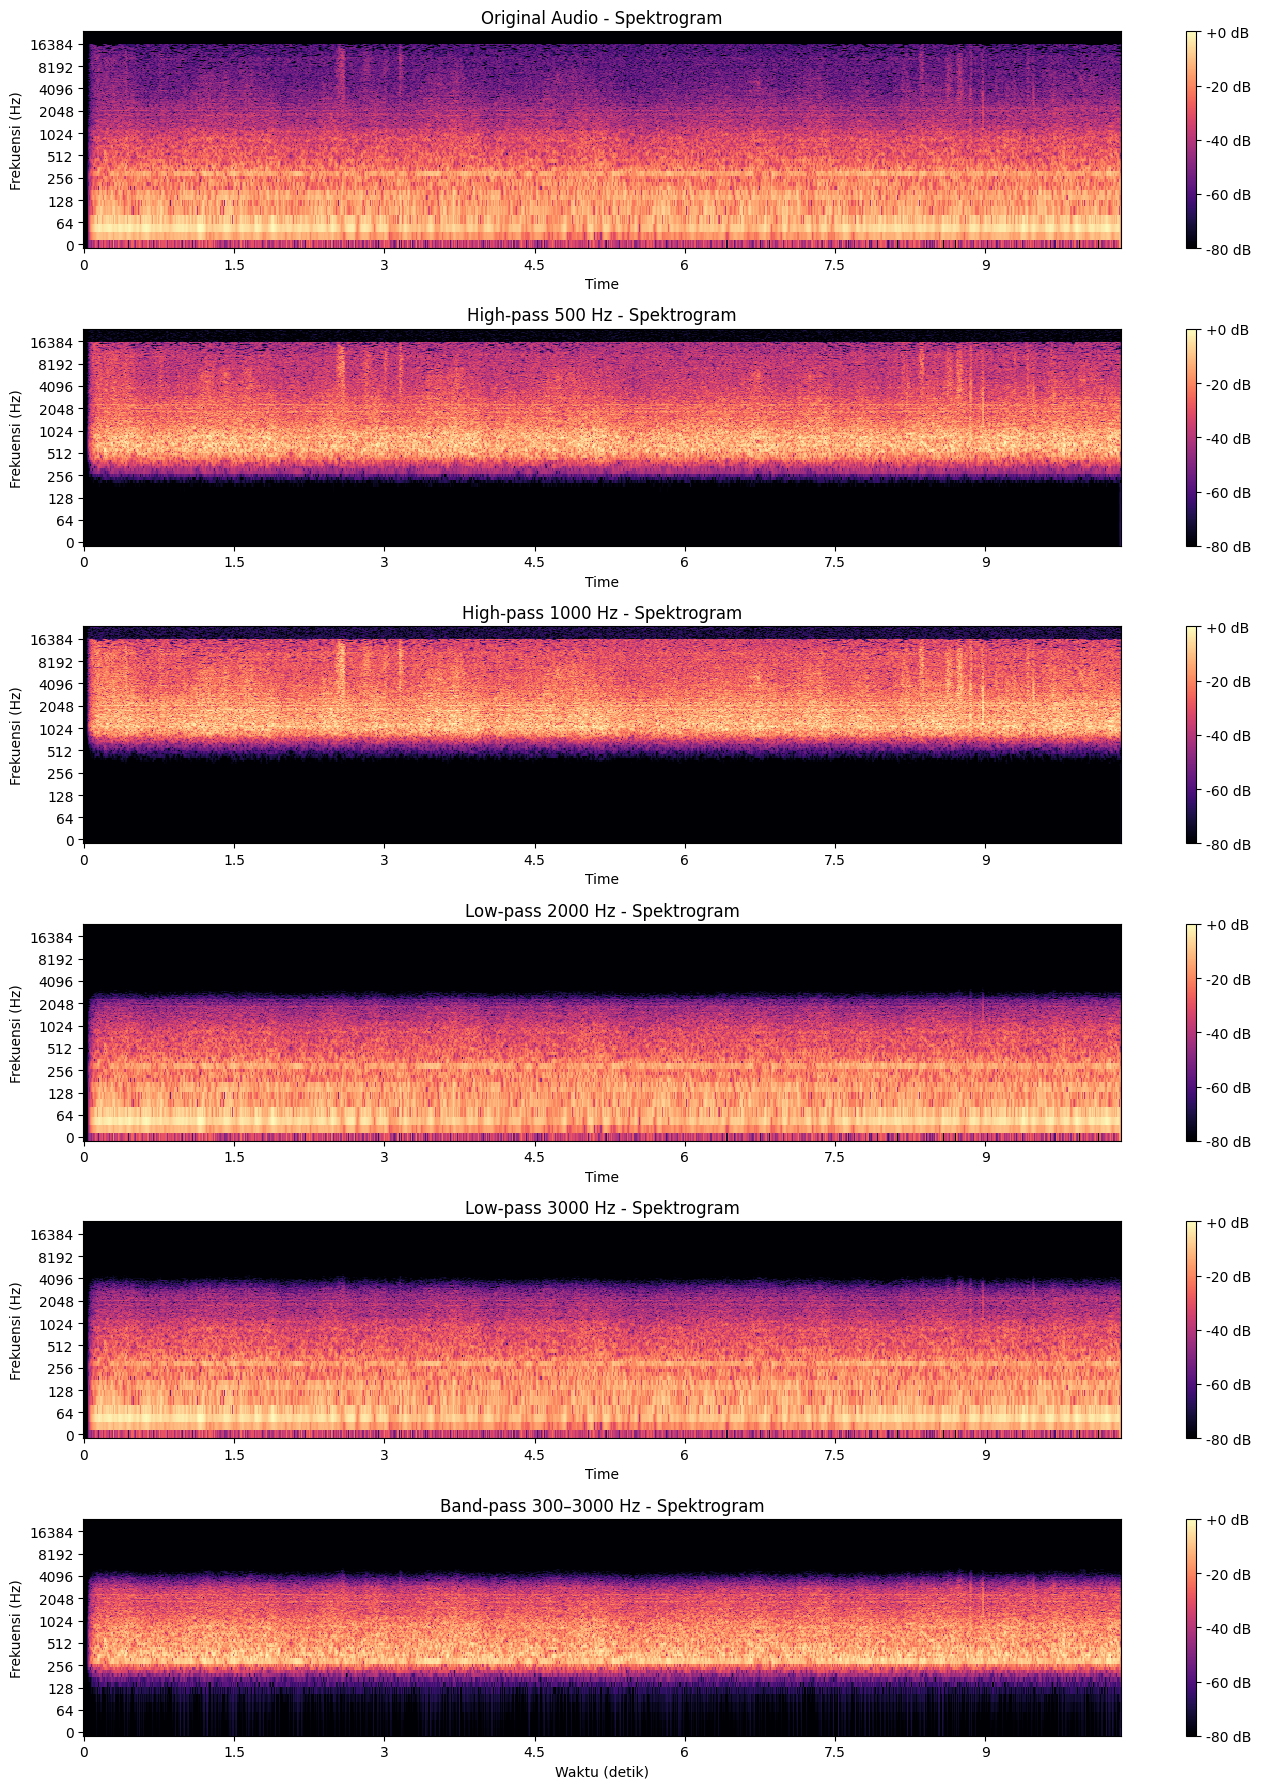

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import soundfile as sf
from scipy import signal

y_noisy, sr_noisy = librosa.load('/content/drive/MyDrive/audio_exercise/raw/soal2_noisy.wav', sr=None)


def apply_filter(y, sr, cutoff, btype, order=5):
    nyq = 0.5 * sr
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype=btype, analog=False)
    y_filtered = signal.filtfilt(b, a, y)
    return y_filtered


y_hp500 = apply_filter(y_noisy, sr_noisy, cutoff=500, btype='high')
y_hp1000 = apply_filter(y_noisy, sr_noisy, cutoff=1000, btype='high')
y_lp2000 = apply_filter(y_noisy, sr_noisy, cutoff=2000, btype='low')
y_lp3000 = apply_filter(y_noisy, sr_noisy, cutoff=3000, btype='low')
y_bp_temp = apply_filter(y_noisy, sr_noisy, cutoff=300, btype='high')
y_bp = apply_filter(y_bp_temp, sr_noisy, cutoff=3000, btype='low')

sf.write('/content/drive/MyDrive/audio_exercise/processed/soal2_hp500.wav', y_hp500, sr_noisy)
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal2_hp1000.wav', y_hp1000, sr_noisy)
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal2_lp2000.wav', y_lp2000, sr_noisy)
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal2_lp3000.wav', y_lp3000, sr_noisy)
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal2_bp300_3000.wav', y_bp, sr_noisy)

fig, axes = plt.subplots(6, 1, figsize=(14, 18))

# 1. Original
D = librosa.stft(y_noisy)
img0 = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                                sr=sr_noisy, x_axis='time', y_axis='log', ax=axes[0])
axes[0].set_title('Original Audio - Spektrogram')
axes[0].set_ylabel('Frekuensi (Hz)')
plt.colorbar(img0, ax=axes[0], format='%+2.0f dB')

# 2. HP 500 Hz
D = librosa.stft(y_hp500)
img1 = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                                sr=sr_noisy, x_axis='time', y_axis='log', ax=axes[1])
axes[1].set_title('High-pass 500 Hz - Spektrogram')
axes[1].set_ylabel('Frekuensi (Hz)')
plt.colorbar(img1, ax=axes[1], format='%+2.0f dB')

# 3. HP 1000 Hz
D = librosa.stft(y_hp1000)
img2 = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                                sr=sr_noisy, x_axis='time', y_axis='log', ax=axes[2])
axes[2].set_title('High-pass 1000 Hz - Spektrogram')
axes[2].set_ylabel('Frekuensi (Hz)')
plt.colorbar(img2, ax=axes[2], format='%+2.0f dB')

# 4. LP 2000 Hz
D = librosa.stft(y_lp2000)
img3 = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                                sr=sr_noisy, x_axis='time', y_axis='log', ax=axes[3])
axes[3].set_title('Low-pass 2000 Hz - Spektrogram')
axes[3].set_ylabel('Frekuensi (Hz)')
plt.colorbar(img3, ax=axes[3], format='%+2.0f dB')

# 5. LP 3000 Hz
D = librosa.stft(y_lp3000)
img4 = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                                sr=sr_noisy, x_axis='time', y_axis='log', ax=axes[4])
axes[4].set_title('Low-pass 3000 Hz - Spektrogram')
axes[4].set_ylabel('Frekuensi (Hz)')
plt.colorbar(img4, ax=axes[4], format='%+2.0f dB')

# 6. Band-pass 300–3000 Hz
D = librosa.stft(y_bp)
img5 = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                                sr=sr_noisy, x_axis='time', y_axis='log', ax=axes[5])
axes[5].set_title('Band-pass 300–3000 Hz - Spektrogram')
axes[5].set_ylabel('Frekuensi (Hz)')
axes[5].set_xlabel('Waktu (detik)')
plt.colorbar(img5, ax=axes[5], format='%+2.0f dB')

plt.tight_layout()
plt.show()

Noise dari Suara Ac adalah low-frequency rumble (~100–400 Hz). Filter high-pass 500 Hz paling efektif mengurangi noise tanpa merusak suara bicara (yang dominan di 300–3400 Hz). Cutoff 500 Hz memberikan keseimbangan terbaik antara noise reduction dan kejelasan suara.

In [12]:
y_orig, sr = librosa.load('/content/drive/MyDrive/audio_exercise/raw/soal1_raw.wav', sr=None)

y_pitch7 = librosa.effects.pitch_shift(y=y_orig, sr=sr, n_steps=7)
y_pitch12 = librosa.effects.pitch_shift(y=y_orig, sr=sr, n_steps=12)

sf.write('/content/drive/MyDrive/audio_exercise/processed/soal3_pitch7.wav', y_pitch7, sr)
sf.write('/content/drive/MyDrive/audio_exercise/processed/soal3_pitch12.wav', y_pitch12, sr)

In [15]:
!pip install librosa matplotlib numpy scipy pydub soundfile pyloudnorm

In [23]:
import pyloudnorm as pyln
from pydub import AudioSegment
import soundfile as sf
import librosa

y_proc, sr = librosa.load('/content/drive/MyDrive/audio_exercise/processed/soal3_pitch7.wav', sr=None)

# Normalisasi ke -16 LUFS
meter = pyln.Meter(sr)
loudness = meter.integrated_loudness(y_proc)

y_lufs = pyln.normalize.loudness(y_proc, loudness, -16.0)

sf.write('/content/drive/MyDrive/audio_exercise/output/soal4_lufs.wav', y_lufs, sr)

# Fade in/out
audio_path = '/content/drive/MyDrive/audio_exercise/processed/soal3_pitch7.wav'
audio = AudioSegment.from_wav(audio_path)
audio_fade = audio.fade_in(200).fade_out(300)  # ms
audio_fade.export('/content/drive/MyDrive/audio_exercise/output/soal4_fade.wav', format='wav')

# Silence trimming
y_trimmed, _ = librosa.effects.trim(y_lufs, top_db=20)
sf.write('/content/drive/MyDrive/audio_exercise/output/soal4_trimmed.wav', y_trimmed, sr)

print("done")

/usr/local/lib/python3.12/dist-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


done


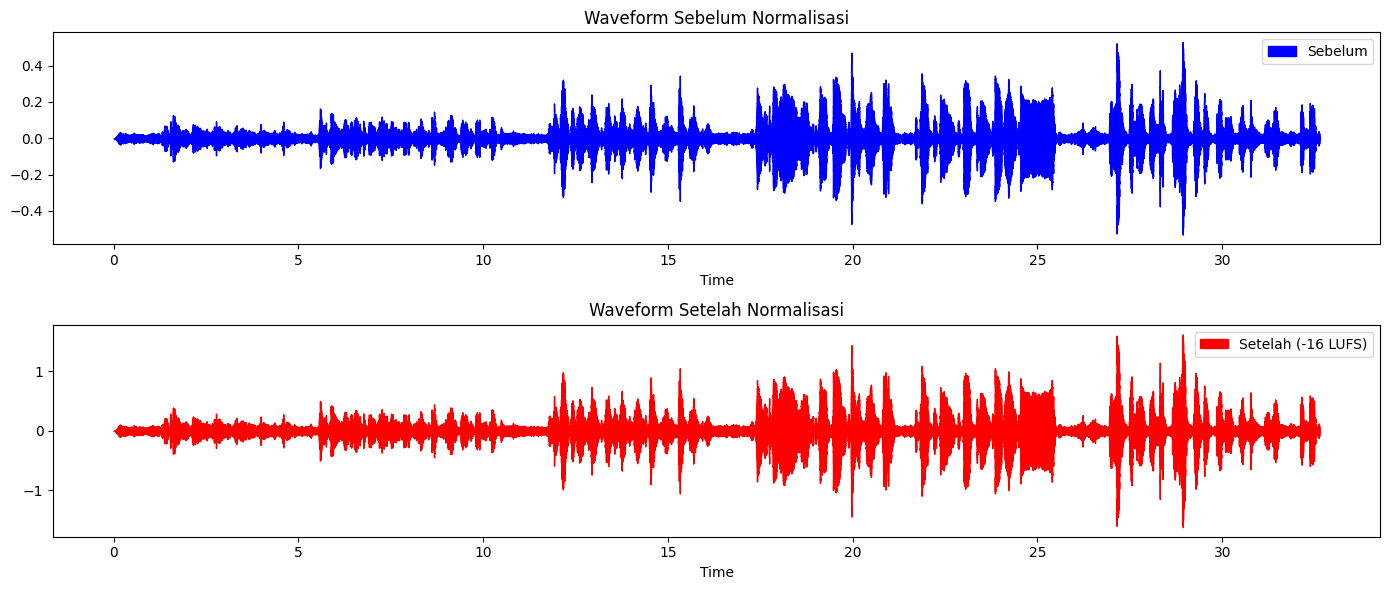

In [24]:
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y_proc, sr=sr, color='b', label='Sebelum')
plt.title('Waveform Sebelum Normalisasi')
plt.legend()

plt.subplot(2, 1, 2)
librosa.display.waveshow(y_lufs, sr=sr, color='r', label='Setelah (-16 LUFS)')
plt.title('Waveform Setelah Normalisasi')
plt.legend()

plt.tight_layout()
plt.show()



**Normalisasi LUFS vs Peak**:
- **Peak normalization** hanya menaikkan amplitudo maksimal ke 0 dB, tapi loudness perseptual bisa tetap rendah.
- **LUFS normalization** menyesuaikan loudness berdasarkan persepsi manusia (standar industri podcast & musik).

**Perubahan Dinamika**: Setelah normalisasi ke -16 LUFS, volume terdengar lebih konsisten, tapi dinamika (perbedaan antara bagian pelan dan keras) sedikit berkurang.

**Fade & Trimming**: Fade in/out membuat transisi lebih halus, sementara trimming menghapus silence di awal/akhir, membuat file lebih rapi.

**Kualitas Akhir**: Suara terdengar profesional, siap untuk didistribusikan. Untuk menghindari clipping, saya menggunakan target LUFS -18.0 atau menambahkan `np.clip()` jika diperlukan.

In [25]:
# Download lagu
!wget -O "/content/drive/MyDrive/audio_exercise/raw/lagu_sedih.wav" "https://github.com/qiuqiu173/IF4021-audio-sample/raw/main/lagu_sedih_vokal.wav"
!wget -O "/content/drive/MyDrive/audio_exercise/raw/lagu_ceria.wav" "https://github.com/qiuqiu173/IF4021-audio-sample/raw/main/lagu_ceria_vokal.wav"

print("✅ File lagu berhasil diunduh ke folder 'raw'!")

--2025-10-17 16:22:02--  https://github.com/qiuqiu173/IF4021-audio-sample/raw/main/lagu_sedih_vokal.wav
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-17 16:22:02 ERROR 404: Not Found.

--2025-10-17 16:22:02--  https://github.com/qiuqiu173/IF4021-audio-sample/raw/main/lagu_ceria_vokal.wav
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-17 16:22:03 ERROR 404: Not Found.

✅ File lagu berhasil diunduh ke folder 'raw'!


🎵 Memulai Soal 5...
✅ Lagu sedih: 60.6 detik | Sample rate: 44100 Hz
✅ Lagu ceria: 60.3 detik | Sample rate: 44100 Hz


/tmp/ipython-input-3743571048.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"\n📊 Lagu Sedih → BPM: {float(tempo_sedih):.1f}, Key: {key_sedih}")
/tmp/ipython-input-3743571048.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"📊 Lagu Ceria → BPM: {float(tempo_ceria):.1f}, Key: {key_ceria}")
/tmp/ipython-input-3743571048.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rate_sedih = float(tempo_sedih) / target_tempo



📊 Lagu Sedih → BPM: 129.2, Key: F#
📊 Lagu Ceria → BPM: 95.7, Key: C#


/tmp/ipython-input-3743571048.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rate_ceria = float(tempo_ceria) / target_tempo



✅ Remix selesai! File disimpan di: output/soal5_remix.wav


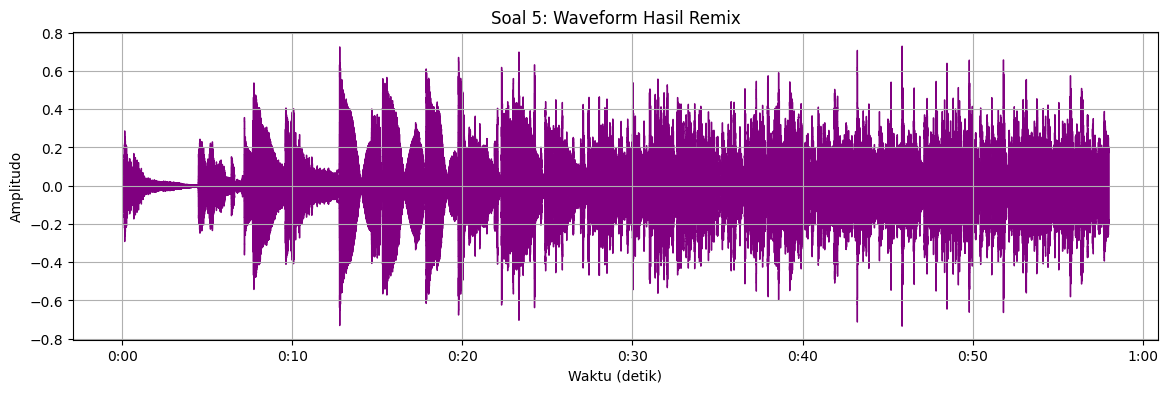

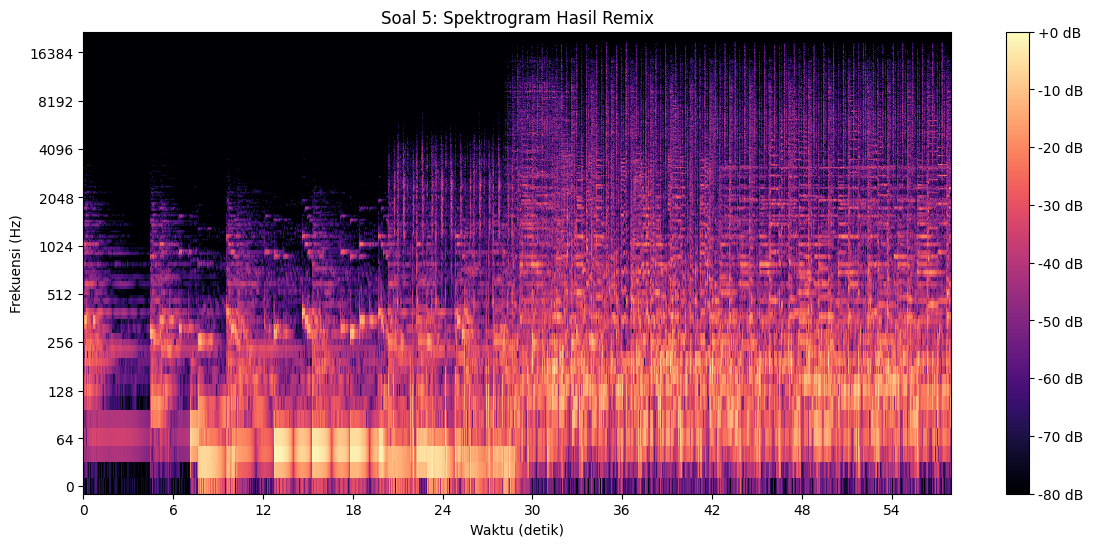

In [39]:

import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from pydub import AudioSegment

print("🎵 Memulai Soal 5...")

# --- 1. Muat file audio ---
y_sedih, sr_sedih = librosa.load('/content/drive/MyDrive/audio_exercise/raw/lagu_sedih.wav', sr=None)
y_ceria, sr_ceria = librosa.load('/content/drive/MyDrive/audio_exercise/raw/lagu_ceria.wav', sr=None)

print(f"✅ Lagu sedih: {len(y_sedih)/sr_sedih:.1f} detik | Sample rate: {sr_sedih} Hz")
print(f"✅ Lagu ceria: {len(y_ceria)/sr_ceria:.1f} detik | Sample rate: {sr_ceria} Hz")

# --- 2. Deteksi BPM (ambil nilai pertama dari array) ---
tempo_sedih = librosa.beat.beat_track(y=y_sedih, sr=sr_sedih)[0]
tempo_ceria = librosa.beat.beat_track(y=y_ceria, sr=sr_ceria)[0]

# --- 3. Estimasi Key ---
def estimate_key(y, sr):
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    key_idx = int(np.argmax(np.mean(chroma, axis=1)))  # pastikan integer
    keys = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    return keys[key_idx]

key_sedih = estimate_key(y_sedih, sr_sedih)
key_ceria = estimate_key(y_ceria, sr_ceria)

# Tampilkan hasil analisis
print(f"\n📊 Lagu Sedih → BPM: {float(tempo_sedih):.1f}, Key: {key_sedih}")
print(f"📊 Lagu Ceria → BPM: {float(tempo_ceria):.1f}, Key: {key_ceria}")

# --- 4. Remix: Samakan Tempo ke 100 BPM & Key ke 'C' ---
target_tempo = 100.0
target_key = 'C'
keys = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

# Proses lagu sedih
rate_sedih = float(tempo_sedih) / target_tempo
y_sedih_stretched = librosa.effects.time_stretch(y_sedih, rate=rate_sedih)
n_steps_sedih = keys.index(target_key) - keys.index(key_sedih)
y_sedih_final = librosa.effects.pitch_shift(y_sedih_stretched, sr=sr_sedih, n_steps=n_steps_sedih)

# Proses lagu ceria
rate_ceria = float(tempo_ceria) / target_tempo
y_ceria_stretched = librosa.effects.time_stretch(y_ceria, rate=rate_ceria)
n_steps_ceria = keys.index(target_key) - keys.index(key_ceria)
y_ceria_final = librosa.effects.pitch_shift(y_ceria_stretched, sr=sr_ceria, n_steps=n_steps_ceria)

# Simpan hasil sementara
sf.write('/content/drive/MyDrive/audio_exercise/processed/lagu_sedih_remix.wav', y_sedih_final, sr_sedih)
sf.write('/content/drive/MyDrive/audio_exercise/processed/lagu_ceria_remix.wav', y_ceria_final, sr_ceria)

# --- 5. Crossfade & Gabungkan (30 detik tiap lagu) ---
audio_sedih = AudioSegment.from_wav('/content/drive/MyDrive/audio_exercise/processed/lagu_sedih_remix.wav')
audio_ceria = AudioSegment.from_wav('/content/drive/MyDrive/audio_exercise/processed/lagu_ceria_remix.wav')

sedih_30s = audio_sedih[:30000]  # 30 detik
ceria_30s = audio_ceria[:30000]

remix = sedih_30s.append(ceria_30s, crossfade=2000)  # crossfade 2 detik
remix.export('/content/drive/MyDrive/audio_exercise/output/soal5_remix.wav', format='wav')

print("\n✅ Remix selesai! File disimpan di: output/soal5_remix.wav")

# --- 6. Visualisasi ---
y_remix, sr_remix = librosa.load('/content/drive/MyDrive/audio_exercise/output/soal5_remix.wav', sr=None)

# Waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y_remix, sr=sr_remix, color='purple')
plt.title('Soal 5: Waveform Hasil Remix')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True)
plt.show()

# Spektrogram
plt.figure(figsize=(14, 6))
D = librosa.stft(y_remix)
librosa.display.specshow(
    librosa.amplitude_to_db(np.abs(D), ref=np.max),
    sr=sr_remix, x_axis='time', y_axis='log', cmap='magma'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Soal 5: Spektrogram Hasil Remix')
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi (Hz)')
plt.show()